# Scan-rescan stability: stitch acquisition

Analyzes lesion volume scan-rescan stability (`volume_stability.csv`, merged into `output_eval_stitch_tta/merged.csv`) for the `stitch` acquisition, comparing across models/runs (`r20250909`, `r20260629`, `r20260703`).

Note: unlike the upper/lower evaluation, the stitch folder layout is `<root>/<model>/volume_stability.csv` (no upper/lower subfolder), so the `model` column is the grouping variable here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_rows", 200)

In [2]:
DATA_PATH = "../../output_eval_stitch_tta/merged.csv"

df = pd.read_csv(DATA_PATH)
df["case"] = df["subject"] + "_" + df["session"]
df.head()

,subject,session,model,volume_run1_mm3,volume_run2_mm3,mean_volume_mm3,abs_vol_diff_mm3,cv_percent,run,acquisition,case
0,sub-001,ses-M0,r20250909,0.803661,1.071548,0.937604,0.267887,20.203051,output_eval_stitch_tta,r20250909,sub-001_ses-M0
1,sub-002,ses-M0,r20250909,0.000000,0.000000,0.000000,0.000000,0.000000,output_eval_stitch_tta,r20250909,sub-002_ses-M0
2,sub-003,ses-M0,r20250909,95.098159,79.560995,87.329577,15.537164,12.580427,output_eval_stitch_tta,r20250909,sub-003_ses-M0
3,sub-004,ses-M0,r20250909,446.840928,504.437331,475.639130,57.596403,8.562543,output_eval_stitch_tta,r20250909,sub-004_ses-M0
4,sub-005,ses-M0,r20250909,279.953932,317.728257,298.841095,37.774325,8.938021,output_eval_stitch_tta,r20250909,sub-005_ses-M0


## Overview

In [3]:
models = sorted(df["model"].unique())
print(f"rows: {len(df)}")
print(f"subjects: {sorted(df['subject'].unique())}")
print(f"models: {models}")
df.groupby("model").size().rename("n_cases").to_frame()

rows: 15
subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']
models: ['r20250909', 'r20260629', 'r20260703']


,n_cases
model,
r20250909,5
r20260629,5
r20260703,5


## Summary statistics per model

In [4]:
summary = df.groupby("model").agg(
    n=("cv_percent", "size"),
    cv_mean=("cv_percent", "mean"),
    cv_std=("cv_percent", "std"),
    cv_median=("cv_percent", "median"),
    mean_volume_mm3=("mean_volume_mm3", "mean"),
    abs_vol_diff_mm3=("abs_vol_diff_mm3", "mean"),
)
summary

,n,cv_mean,cv_std,cv_median,mean_volume_mm3,abs_vol_diff_mm3
model,,,,,,
r20250909,5,10.056809,7.313323,8.938021,172.549481,22.235156
r20260629,5,24.325272,9.654115,21.295518,414.932261,129.387601
r20260703,5,37.444727,31.824158,27.106928,244.129473,86.207319


## CV distribution across models

/var/folders/_2/l62mvrbx76l6nx_408gf05140000gn/T/ipykernel_34261/3392208473.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=models, showmeans=True)


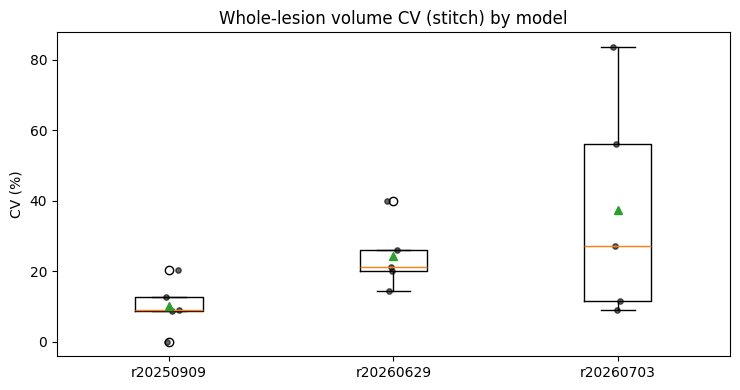

In [5]:
fig, ax = plt.subplots(figsize=(5 * len(models) / 2, 4))

data = [df[df["model"] == m]["cv_percent"].dropna() for m in models]
ax.boxplot(data, labels=models, showmeans=True)
for i, m in enumerate(models):
    y = df[df["model"] == m]["cv_percent"].dropna()
    ax.scatter(np.full(len(y), i + 1) + np.random.uniform(-0.05, 0.05, len(y)), y, alpha=0.6, color="black", s=15)

ax.set_ylabel("CV (%)")
ax.set_title("Whole-lesion volume CV (stitch) by model")
fig.tight_layout()
plt.show()

## Per-subject comparison across models

Same subject/session, CV across models, one line per case.

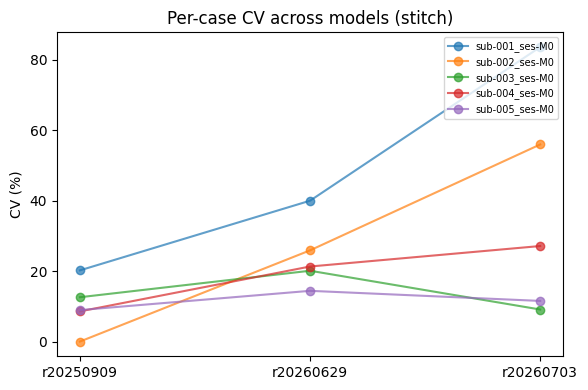

model,r20250909,r20260629,r20260703
case,,,
sub-001_ses-M0,20.203051,39.966905,83.567165
sub-002_ses-M0,0.000000,25.877532,55.926495
sub-003_ses-M0,12.580427,20.093351,9.094621
sub-004_ses-M0,8.562543,21.295518,27.106928
sub-005_ses-M0,8.938021,14.393054,11.528427


In [6]:
pivot = df.pivot_table(index="case", columns="model", values="cv_percent")

fig, ax = plt.subplots(figsize=(6, 4))
for case, row in pivot.iterrows():
    ax.plot(models, [row.get(m) for m in models], marker="o", alpha=0.7, label=case)
ax.set_ylabel("CV (%)")
ax.set_title("Per-case CV across models (stitch)")
ax.legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()

pivot

## Run-1 vs run-2 volume agreement

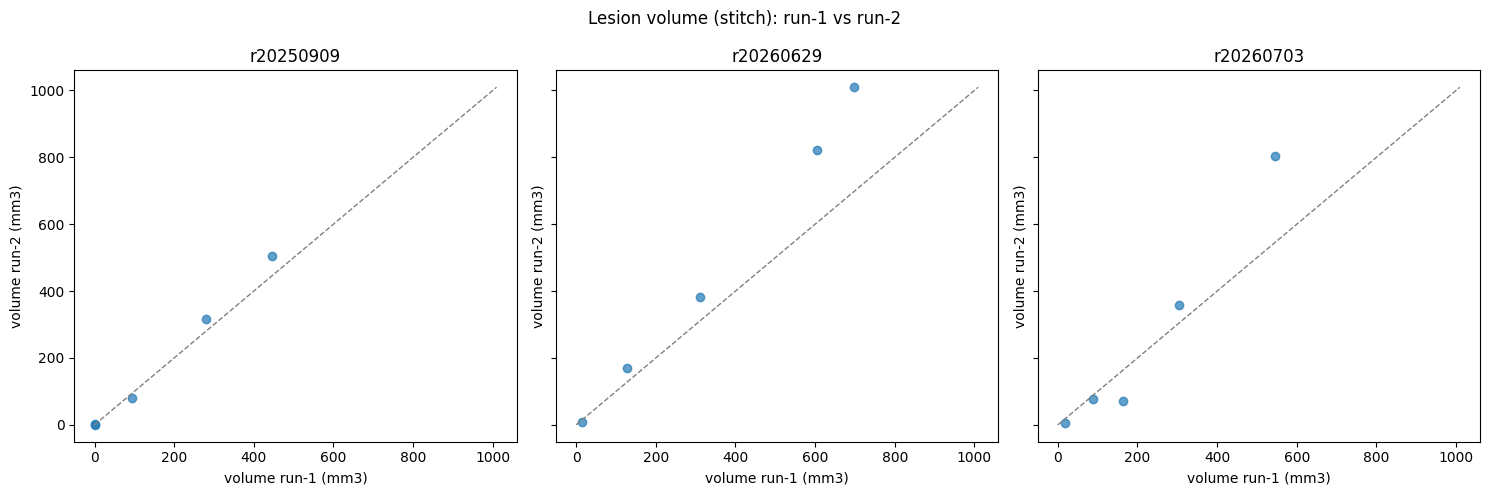

In [7]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5), sharex=True, sharey=True)
if len(models) == 1:
    axes = [axes]

max_vol = df[["volume_run1_mm3", "volume_run2_mm3"]].max().max()

for ax, m in zip(axes, models):
    sub = df[df["model"] == m]
    ax.scatter(sub["volume_run1_mm3"], sub["volume_run2_mm3"], alpha=0.7)
    ax.plot([0, max_vol], [0, max_vol], linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("volume run-1 (mm3)")
    ax.set_ylabel("volume run-2 (mm3)")
    ax.set_title(m)

fig.suptitle("Lesion volume (stitch): run-1 vs run-2")
fig.tight_layout()
plt.show()

## Zero / near-zero lesion volume cases

Cases where the mean predicted lesion volume across run-1/run-2 is (near) zero, i.e. no lesion detected.

In [8]:
zero_cases = df[df["mean_volume_mm3"] < 1e-6][["model", "case", "volume_run1_mm3", "volume_run2_mm3"]]
zero_cases

,model,case,volume_run1_mm3,volume_run2_mm3
1,r20250909,sub-002_ses-M0,0.0,0.0


## Statistical comparison across models (paired by case)

Friedman test (omnibus, requires >=3 models) plus pairwise Wilcoxon signed-rank tests on `cv_percent`.

In [9]:
paired = pivot.dropna()

if len(models) >= 3 and len(paired) >= 2:
    stat, p = stats.friedmanchisquare(*[paired[m] for m in models])
    print(f"Friedman test (n={len(paired)} paired cases): statistic={stat:.4f}, p={p:.4g}")
else:
    print(f"Not enough models/paired data for Friedman test (n_models={len(models)}, n_paired={len(paired)})")

print("\nPairwise Wilcoxon signed-rank tests:")
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        m1, m2 = models[i], models[j]
        sub = paired[[m1, m2]].dropna()
        if len(sub) < 2:
            print(f"  {m1} vs {m2}: not enough paired data (n={len(sub)})")
            continue
        stat, p = stats.wilcoxon(sub[m1], sub[m2])
        print(f"  {m1} vs {m2} (n={len(sub)}): statistic={stat:.4f}, p={p:.4g}")

Friedman test (n=5 paired cases): statistic=4.8000, p=0.09072

Pairwise Wilcoxon signed-rank tests:
  r20250909 vs r20260629 (n=5): statistic=0.0000, p=0.0625
  r20250909 vs r20260703 (n=5): statistic=2.0000, p=0.1875
  r20260629 vs r20260703 (n=5): statistic=4.0000, p=0.4375
